# Experiment 2: Vision Ecosystems under Continuous Transformations

This notebook analyzes Exp2 result JSON files from `results_exp22`.

Goal:
Evaluate whether adaptive search can find inputs where the target model
cannot be explained by peer models under continuous transformations.


## Experiment Pipeline

The experiment consists of three stages:

1. Fitting:
   fit a convex mixture of peer models to approximate the target.

2. Search:
   fix the fitted weights and search for transformations with high residual.

3. Holdout:
   evaluate the discovered transformation on unseen data.

## Experimental Setup

Target model:
- ConvNeXt

Peer models:
- ResNet
- EfficientNet
- ViT

Transformations:
- blur
- brightness
- contrast
- rotation
- FGSM

### Search stage

For each query, a transformation parameter θ is sampled and applied to a batch of images.
The residual reward is computed as:

- Residual:
  R(x, θ) = |y_t − ŵᵀ y_peers|

- Pairwise baseline:
  P(x, θ) = max_j |y_t − y_j|

The average reward over the batch is used as the score of θ.
After all queries, the transformation with the highest score is selected.

### Holdout stage

The best transformation θ* found during search is fixed and evaluated on unseen holdout samples.

No further search or parameter updates are performed during holdout.
The final metrics are averaged across 5 random seeds.

## 1. Setup

In [3]:
import sys

print(sys.executable)
!{sys.executable} -m pip install matplotlib numpy pandas

/zhome/43/2/214639/project/venv/bin/python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 60.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 64.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [matplotlib]0 [matplotlib]esources]


In [13]:
import json
import glob
import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200


## 2. Load result files

Modify `RESULT_DIR` if your result folder changes.

In [ ]:
RESULT_DIR = '/home/s243815/Adaptive-Model-Uniqueness/results/thesis_exp2'
json_files = sorted(glob.glob(os.path.join(RESULT_DIR, '*.json')))
print(f'Found {len(json_files)} JSON files')
for p in json_files:
    print(os.path.basename(p))


Found 6 JSON files
cma_standard_fgsm_samples300_fit150_budget300_20260429_211154.json
cma_standard_none_samples300_fit150_budget300_20260429_101634.json
grid1d_standard_none_samples300_fit150_budget300_20260502_021143.json
lhs_standard_none_samples300_fit150_budget300_20260501_201235.json
random_standard_fgsm_samples300_fit150_budget300_20260501_122718.json
random_standard_none_samples300_fit150_budget300_20260429_140752.json


In [15]:
all_runs = []

for path in json_files:
    with open(path, 'r') as f:
        data = json.load(f)

    method = data.get('method') or data.get('search_method')
    metrics = data.get('metrics', {})
    config = data.get('config', {})
    attack_mode = config.get('attack_mode')

    all_runs.append({
        'path': path,
        'file': os.path.basename(path),
        'method': method,
        'attack_mode': attack_mode,
        'metrics': metrics,
        'config': config,
        'per_seed_results': data.get('per_seed_results', [])
    })

print('Loaded runs:')
for r in all_runs:
    print(r['method'], r['attack_mode'], r['file'])


Loaded runs:
cma fgsm cma_standard_fgsm_samples300_fit150_budget300_20260429_211154.json
cma none cma_standard_none_samples300_fit150_budget300_20260429_101634.json
grid1d none grid1d_standard_none_samples300_fit150_budget300_20260502_021143.json
lhs none lhs_standard_none_samples300_fit150_budget300_20260501_201235.json
random fgsm random_standard_fgsm_samples300_fit150_budget300_20260501_122718.json
random none random_standard_none_samples300_fit150_budget300_20260429_140752.json


## 3. Summary table

This table compares search and holdout metrics across methods and attack modes.

In [16]:
def metric(run, key):
    return run['metrics'].get(key, np.nan)

summary_rows = []
for r in all_runs:
    summary_rows.append({
        'method': r['method'],
        'attack_mode': r['attack_mode'],
        'search_best': metric(r, 'search_best_residual_mean'),
        'holdout_mean': metric(r, 'holdout_mean_residual_mean'),
        'holdout_max': metric(r, 'holdout_max_residual_mean'),
        'holdout_utility': metric(r, 'holdout_mean_utility_mean'),
        'feasible_fraction': metric(r, 'holdout_feasible_fraction_mean'),
        'pairwise_mean': metric(r, 'holdout_mean_pairwise_mean'),
        'pairwise_max': metric(r, 'holdout_max_pairwise_mean'),
        'file': r['file'],
    })

try:
    import pandas as pd
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary.sort_values(['attack_mode', 'method']))
except Exception:
    for row in summary_rows:
        print(row)


,method,attack_mode,search_best,holdout_mean,holdout_max,holdout_utility,feasible_fraction,pairwise_mean,pairwise_max,file
0,cma,fgsm,0.800009,0.382528,0.709532,0.370044,0.717778,0.649330,0.911580,cma_standard_fgsm_samples300_fit150_budget300_...
4,random,fgsm,0.792774,0.374080,0.729170,0.355732,0.684444,0.639253,0.924917,random_standard_fgsm_samples300_fit150_budget3...
1,cma,none,0.686996,0.255361,0.660852,0.487191,0.860000,0.495677,0.892174,cma_standard_none_samples300_fit150_budget300_...
2,grid1d,none,0.585322,0.140151,0.485751,0.593524,0.931111,0.358815,0.783644,grid1d_standard_none_samples300_fit150_budget3...
3,lhs,none,0.650322,0.246132,0.683106,0.482997,0.871111,0.505779,0.864531,lhs_standard_none_samples300_fit150_budget300_...
5,random,none,0.617449,0.237850,0.642763,0.468095,0.866667,0.508808,0.899340,random_standard_none_samples300_fit150_budget3...


## 4. Holdout residual distribution: normal setting

Purpose: check whether high residuals are rare long-tail cases, and compare search methods.

random: 390 feasible holdout samples
cma: 387 feasible holdout samples
lhs: 392 feasible holdout samples
grid1d: 419 feasible holdout samples
Saved to /zhome/43/2/214639/project/master-thesis-code-/results_exp22/notebook_histogram_normal_all_methods.png


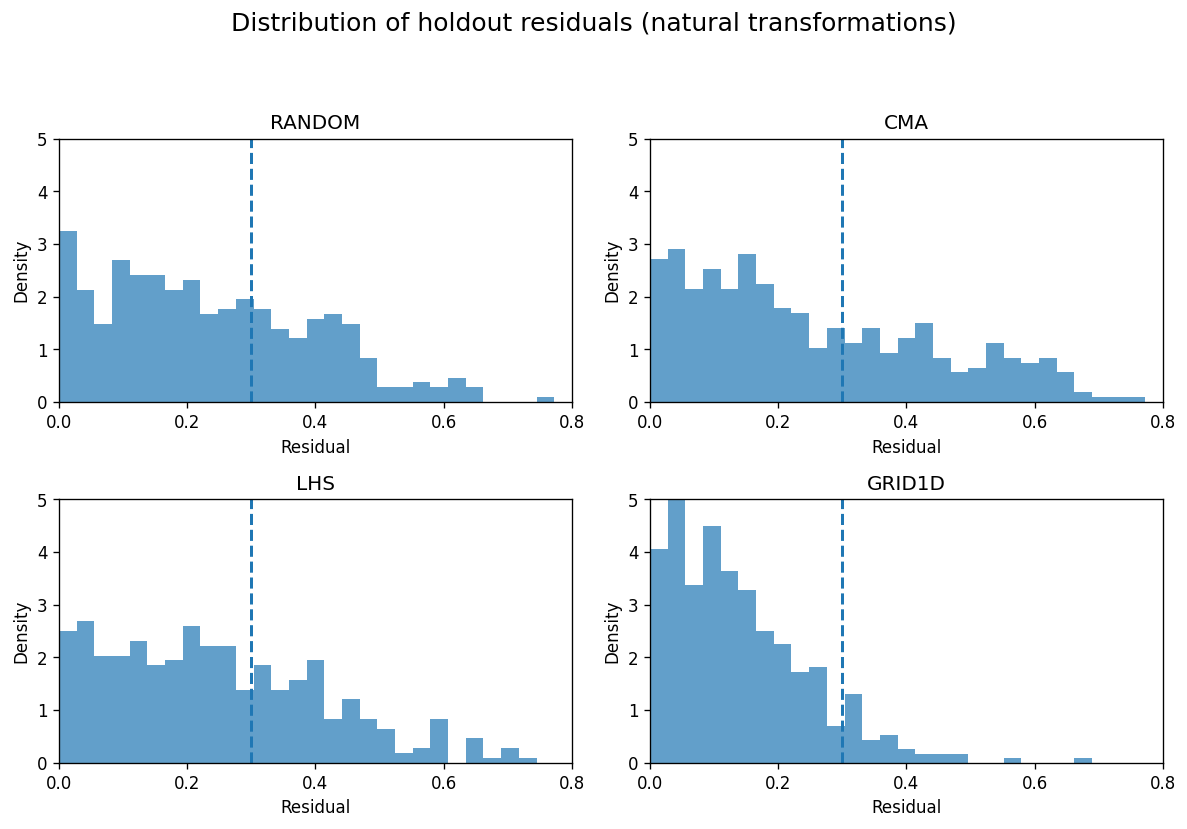

In [17]:
def collect_per_sample_residuals(target_attack_mode='none', methods=None):
    if methods is None:
        methods = ['random', 'cma', 'lhs', 'grid1d']

    residuals = defaultdict(list)

    for run in all_runs:
        for item in run['per_seed_results']:
            method = item.get('search_method')
            if method not in methods:
                continue
            if item.get('attack_mode') != target_attack_mode:
                continue

            holdout_key = 'holdout_summary_fgsm' if target_attack_mode == 'fgsm' else 'holdout_summary_normal'
            per_sample = item.get(holdout_key, {}).get('per_sample_residuals', [])

            for sample in per_sample:
                if sample.get('feasible', False):
                    residuals[method].append(float(sample['residual']))

    return residuals

def plot_residual_histograms(target_attack_mode='none', methods=None, out_name=None):
    if methods is None:
        methods = ['random', 'cma', 'lhs', 'grid1d']
    residuals = collect_per_sample_residuals(target_attack_mode, methods)

    for m in methods:
        print(f'{m}: {len(residuals[m])} feasible holdout samples')

    n = len(methods)
    if n <= 2:
        fig, axes = plt.subplots(1, n, figsize=(10, 4), sharex=True, sharey=True)
    else:
        fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = np.array(axes).ravel()

    bins = np.linspace(0, 0.8, 30)
    for ax, m in zip(axes, methods):
        ax.hist(residuals[m], bins=bins, density=True, alpha=0.7)
        ax.axvline(0.3, linestyle='--', linewidth=1.8)
        ax.set_title(m.upper())
        ax.set_xlabel('Residual')
        ax.set_ylabel('Density')
        ax.set_xlim(0, 0.8)
        ax.set_ylim(0, 5)
        ax.set_yticks([0, 1, 2, 3, 4, 5])
        ax.set_xticks(np.linspace(0, 0.8, 5))
        ax.tick_params(labelbottom=True, labelleft=True)

    for ax in axes[len(methods):]:
        ax.axis('off')

    title_name = 'FGSM perturbations' if target_attack_mode == 'fgsm' else 'natural transformations'
    fig.suptitle(f'Distribution of holdout residuals ({title_name})', fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    if out_name:
        out_path = os.path.join(RESULT_DIR, out_name)
        plt.savefig(out_path)
        print(f'Saved to {out_path}')

    plt.show()

plot_residual_histograms('none', methods=['random', 'cma', 'lhs', 'grid1d'], out_name='notebook_histogram_normal_all_methods.png')


The histograms show the holdout residual distributions under natural transformations.

Key observations:

- Most samples have relatively low residuals,
  while high residual cases only appear in a small number of samples.

- Compared with random search, CMA finds more samples with larger residuals,
  especially in the high-residual region.

- Grid1D mainly stays in lower residual regions,
  suggesting weaker search ability in this setting.

- LHS performs better than Grid1D,
  but still finds fewer extreme residual cases than CMA.

## 5. Holdout residual distribution: FGSM setting

FGSM is used to generate adversarial perturbations that push the target model away from its original prediction.

The goal is to test whether peer models can still explain the target model
when the target behavior is intentionally perturbed.

If the residual increases significantly under FGSM perturbations,
this suggests that peer models fail to track the target model's changes,
indicating stronger uniqueness or weaker substitutability.

random: 308 feasible holdout samples
cma: 323 feasible holdout samples
Saved to /zhome/43/2/214639/project/master-thesis-code-/results_exp22/notebook_histogram_fgsm_random_cma.png


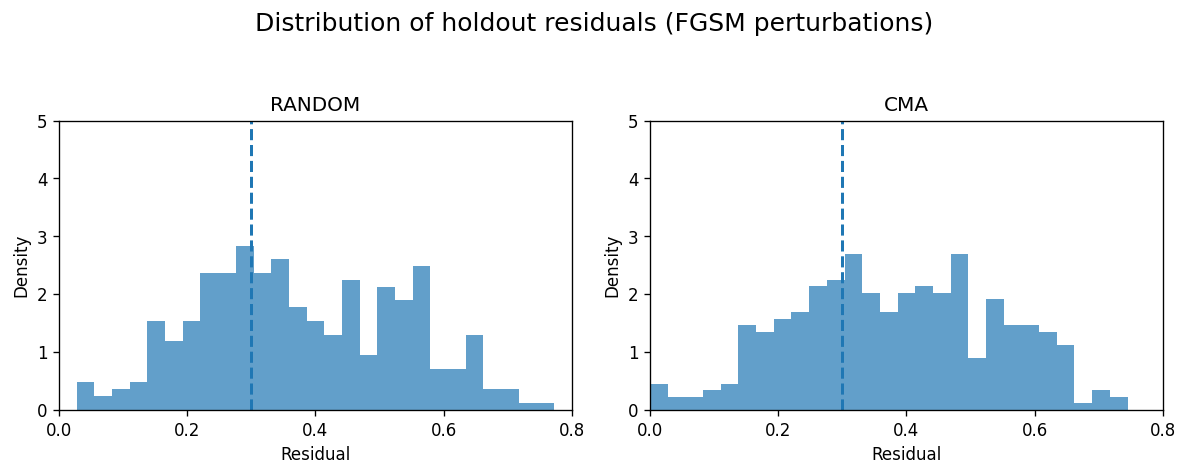

In [18]:
plot_residual_histograms('fgsm', methods=['random', 'cma'], out_name='notebook_histogram_fgsm_random_cma.png')


Under FGSM perturbations, the residual values become larger than in the natural transformation setting.

Compared with random search, CMA finds more high-residual cases,
especially in the right-tail region of the distribution.

This suggests that adaptive search can more effectively discover adversarial inputs
where peer models fail to explain the target model.

At the same time, high residual cases are still relatively sparse,
indicating that these violations mainly occur in a small number of critical samples.

## 6. Pairwise disagreement vs residual

Purpose: show that high pairwise disagreement does not necessarily imply non-substitutability. Residual is stricter because it tests whether a convex mixture of peers can still approximate the target.

Residual: {'random': np.float64(0.23785005960663982), 'cma': np.float64(0.2553606242603557)}
Pairwise: {'random': np.float64(0.5088083608401067), 'cma': np.float64(0.49567700375243506)}
Saved to /zhome/43/2/214639/project/master-thesis-code-/results_exp22/notebook_pairwise_vs_residual_normal.png


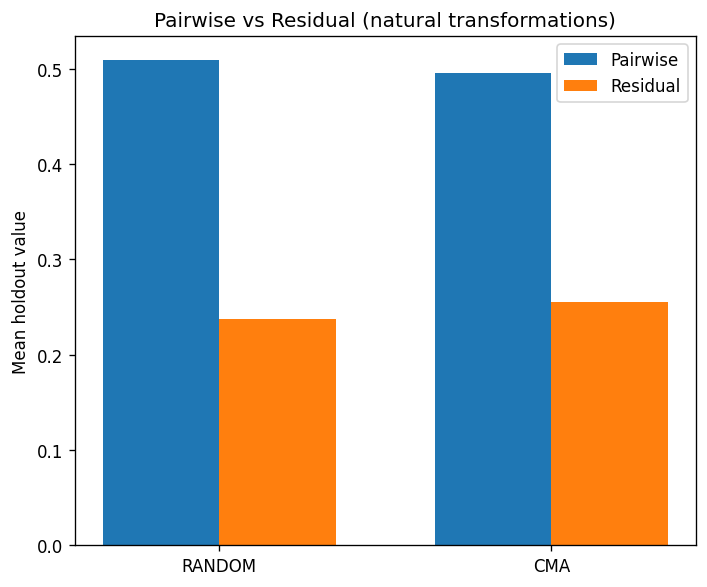

In [19]:
def plot_pairwise_vs_residual(target_attack_mode='none', methods=None, out_name=None):
    if methods is None:
        methods = ['random', 'cma']

    pairwise_vals = {m: [] for m in methods}
    residual_vals = {m: [] for m in methods}

    for run in all_runs:
        for item in run['per_seed_results']:
            if item.get('attack_mode') != target_attack_mode:
                continue
            method = item.get('search_method')
            if method not in methods:
                continue

            holdout_key = 'holdout_summary_fgsm' if target_attack_mode == 'fgsm' else 'holdout_summary_normal'
            holdout = item.get(holdout_key, {})

            if holdout.get('mean_residual') is not None:
                residual_vals[method].append(float(holdout['mean_residual']))
            if holdout.get('mean_pairwise') is not None:
                pairwise_vals[method].append(float(holdout['mean_pairwise']))

    residual_mean = [np.mean(residual_vals[m]) for m in methods]
    pairwise_mean = [np.mean(pairwise_vals[m]) for m in methods]

    print('Residual:', dict(zip(methods, residual_mean)))
    print('Pairwise:', dict(zip(methods, pairwise_mean)))

    x = np.arange(len(methods))
    width = 0.35

    plt.figure(figsize=(6, 5))
    plt.bar(x - width / 2, pairwise_mean, width, label='Pairwise')
    plt.bar(x + width / 2, residual_mean, width, label='Residual')
    plt.xticks(x, [m.upper() for m in methods])
    plt.ylabel('Mean holdout value')
    title_name = 'FGSM perturbations' if target_attack_mode == 'fgsm' else 'natural transformations'
    plt.title(f'Pairwise vs Residual ({title_name})')
    plt.legend()
    plt.tight_layout()

    if out_name:
        out_path = os.path.join(RESULT_DIR, out_name)
        plt.savefig(out_path)
        print(f'Saved to {out_path}')

    plt.show()

plot_pairwise_vs_residual('none', methods=['random', 'cma'], out_name='notebook_pairwise_vs_residual_normal.png')


**Interpretation:** Pairwise disagreement is much higher than residual. This means individual peers can differ from the target, but their combination may still approximate the target. Therefore, pairwise disagreement can overestimate non-substitutability, while residual is a stricter metric.

## 7. Search curves

This section plots the mean best-so-far search residual across seeds.

In [22]:
def plot_search_quantile_convergence(
    target_attack_mode="none",
    methods=None,
    out_name=None
):
    if methods is None:
        methods = ["random", "cma", "lhs", "grid1d"]

    results = defaultdict(list)
    quantile_levels = np.linspace(0.1, 1.0, 10)

    for run in all_runs:
        for item in run["per_seed_results"]:
            method = item.get("search_method")
            attack = item.get("attack_mode")

            if attack != target_attack_mode:
                continue
            if method not in methods:
                continue

            curve = np.asarray(item.get("search_curve", []), dtype=float)
            if len(curve) == 0:
                continue

            # 每个方法/seed 用自己的 search curve 取分位数
            thresholds = np.quantile(curve, quantile_levels)

            queries_needed = []
            for t in thresholds:
                hit = np.where(curve >= t)[0]
                if len(hit) == 0:
                    queries_needed.append(len(curve))
                else:
                    queries_needed.append(int(hit[0]) + 1)

            results[method].append(queries_needed)

    final_mean = {}
    final_std = {}

    for m in methods:
        arr = np.asarray(results[m], dtype=float)
        if arr.size == 0:
            print(f"Warning: no valid results for {m}")
            continue

        final_mean[m] = arr.mean(axis=0)
        final_std[m] = arr.std(axis=0)

    # ===== 打印检查 =====
    print("\n=== Search quantile convergence ===")
    print(f"Attack mode: {target_attack_mode}\n")

    for m in methods:
        if m in final_mean:
            print(m, "mean:", np.round(final_mean[m], 1))
            print(m, "std :", np.round(final_std[m], 1))

    # ===== 画图 =====
    x = quantile_levels * 100

    plt.figure(figsize=(8, 5))

    for m in methods:
        if m not in final_mean:
            continue

        mean = final_mean[m]
        std = final_std[m]

        plt.plot(x, mean, marker="o", label=m)

    title_name = "natural transformations" if target_attack_mode == "none" else "FGSM perturbations"

    plt.xlabel("Relative progress quantile of each method's own search curve (%)")
    plt.ylabel("Queries needed")
    plt.title(f"Relative convergence to each method's own search-curve quantiles\n({title_name})")
    plt.xticks(x)
    plt.legend()
    plt.tight_layout()

    if out_name is None:
        out_name = f"search_quantiles_{target_attack_mode}.png"

    out_path = os.path.join(RESULT_DIR, out_name)
    plt.savefig(out_path, dpi=200)
    plt.show()

    print(f"Saved figure to: {out_path}")

    return final_mean, final_std


=== Search quantile convergence ===
Attack mode: none

random mean: [ 19.2  33.4  39.2  74.4  88.4 116.4 137.2 159.  159.  159. ]
random std : [ 5.  15.2 19.  37.9 51.8 52.1 60.  73.4 73.4 73.4]
cma mean: [ 18.6  36.8  59.   59.  101.2 108.8 117.8 117.8 165.2 196.4]
cma std : [ 4.5 16.6 14.3 14.3 45.4 53.1 62.3 62.3 68.8 77.8]
lhs mean: [ 12.8  21.4  21.4  21.4  67.8  67.8  80.8 120.4 120.4 120.4]
lhs std : [ 7.1 17.4 17.4 17.4 60.6 60.6 79.4 95.4 95.4 95.4]
grid1d mean: [ 21.6  38.6  46.   60.4  76.4  76.4  76.4  76.4 125.2 125.2]
grid1d std : [10.4 19.1 27.2 32.4 49.7 49.7 49.7 49.7 72.2 72.2]


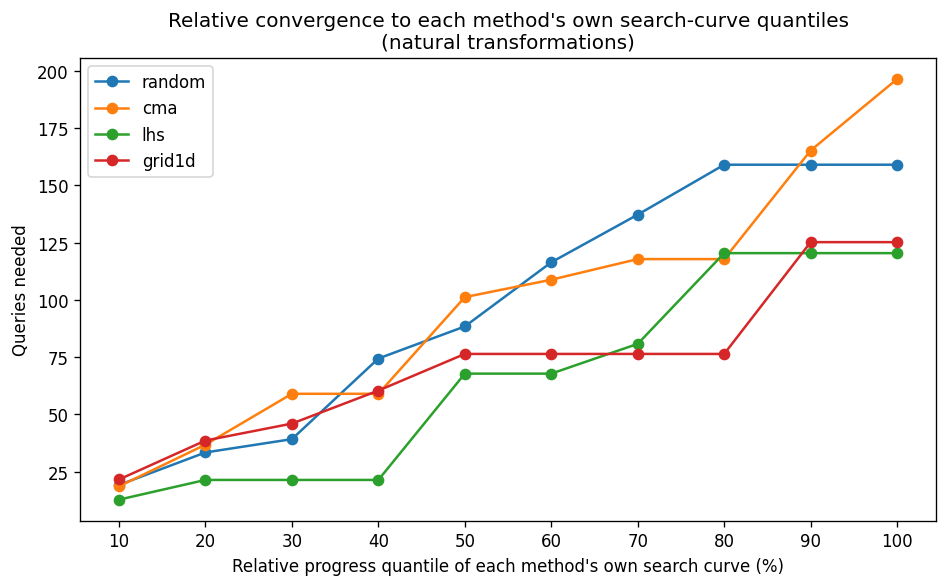

Saved figure to: /zhome/43/2/214639/project/master-thesis-code-/results_exp22/search_quantiles_normal_curve.png


In [23]:
mean_none, std_none = plot_search_quantile_convergence(
    target_attack_mode="none",
    out_name="search_quantiles_normal_curve.png"
)

## 8. Key conclusions

- CMA consistently finds higher residual contexts than random under the cleaned setup.
- High residuals are long-tail critical cases, especially under natural transformations.
- FGSM shifts residual distributions to the right, making hard cases more frequent.
- Pairwise disagreement is not sufficient to imply non-substitutability; residual is stricter and more informative.
- The cleaned setup fixes `w_hat` and normalizes CMA search space, making the results more conservative but more credible.